In [1]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\yashs\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


**Seaborn Tutorial**

**Distribution plots**
- distplot
- joinplot(if we have f1 and f2 features which is called bivariate)
- pairplot(if we have multiple features)

In [2]:
import seaborn as sns


In [3]:
df=sns.load_dataset('Data/tips')
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [14]:
df.dtypes

total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object

**Correlation with Heatmap**
- A correlation heatmap uses colored cells, typically in a monochromatic scale, to show a 2D correlation matrix (table) between two discrete dimensions or event types. It is very important in Feature Selection

This correlation will work on either floating or int data types. if you are data is categorical features it will be not work because they are object dtypes

In [17]:
df.corr(numeric_only=True)

,total_bill,tip,size
total_bill,1.000000,0.675734,0.598315
tip,0.675734,1.000000,0.489299
size,0.598315,0.489299,1.000000


<Axes: >

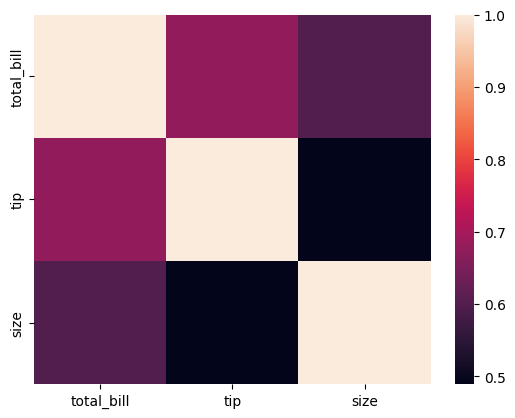

In [18]:
sns.heatmap(df.corr(numeric_only=True))

Heatmap is use for visualization of  the matrix of correlation

**JoinPlot**

- A join plot allows to study the relationship between 2 numeric variables. The central chart display their correlation. It is usually a scatterplot, a hexbin plot, a 2D histogram or a 2D density plot

**UNIVARIATE ANALYSIS**

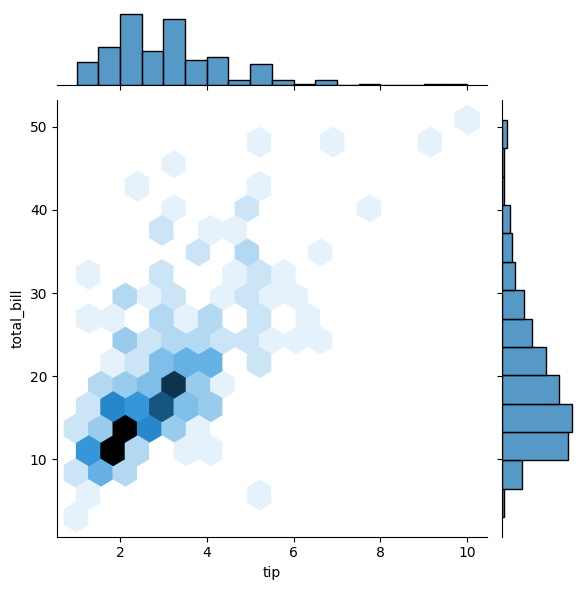

In [19]:
sns.jointplot(x='tip', y='total_bill', data=df, kind='hex')

**Insight from this graph**

- Darker hexagon = more data points
- Lighter = fewer points

- Most customers:

1. Tip ≈ 2–3
2. Bill ≈ 10–20

- That dark region = most common behavior

The graph shows a positive relationship between tip and total bill. As the bill increases, the tip also tends to increase. The scatter plot shows individual data points, while the regression line indicates the trend. The hexbin plot highlights data density, showing that most observations are concentrated around moderate bill and tip values.

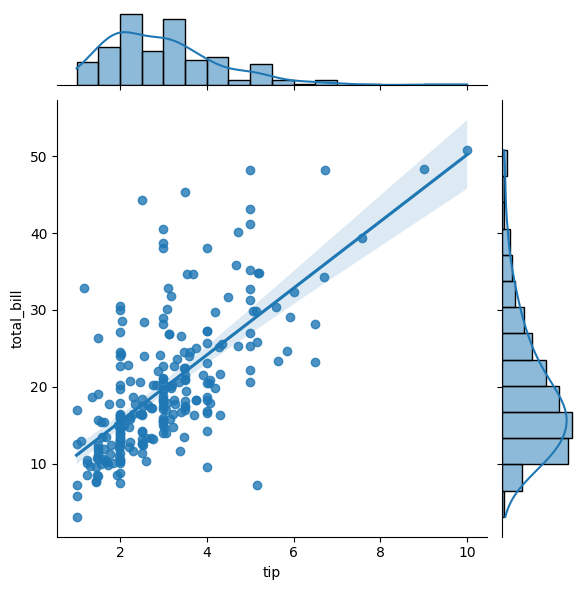

In [20]:
sns.jointplot(x='tip', y='total_bill', data=df, kind='reg')

1. Line in the middle
- show the trends
- As tip increases → total bill also increases

2. Top Histogram
- Distribution of tip
- Most tips are around 2–4

3. Right Histogram
- Distribution of total_bill
- Most bills are around 10–25

The regression line represents a simple model capturing the relationship between tip and total bill. If the model were too simple and failed to capture the trend, it would underfit. If it were too complex and tried to fit every data point, it would overfit. In this case, the linear model provides a good balance by capturing the overall trend without fitting noise.

**Pair plot**

- A “pairs plot” is also known as a scatterplot, in which one variable in the same data row is matched with another variable's value, like this: Pairs plots are just elaborations on this, showing all variables paired with all the other variables

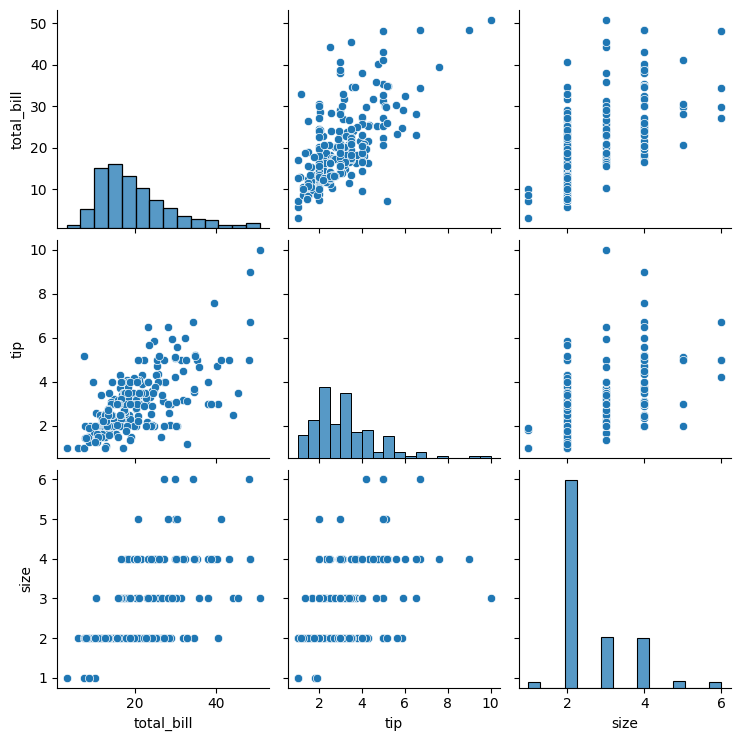

In [22]:
sns.pairplot(df)

hue is used to divide data into different categories using colors

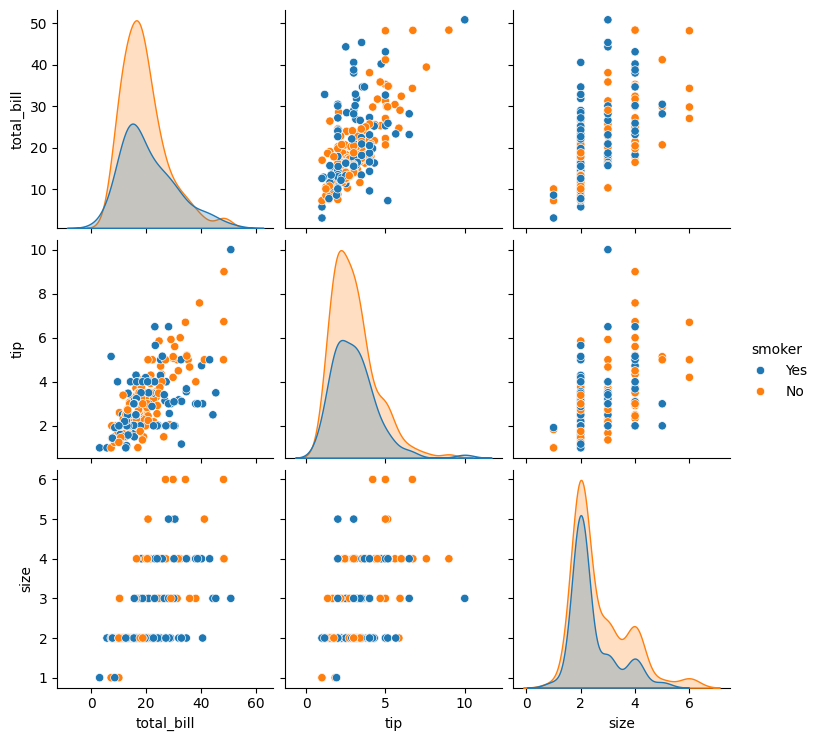

In [24]:
sns.pairplot(df, hue='smoker')

In [25]:
df['smoker'].value_counts()

smoker
No     151
Yes     93
Name: count, dtype: int64

**DISTPLOT**

- Dist plot helps us to check the distribution of the columns feature

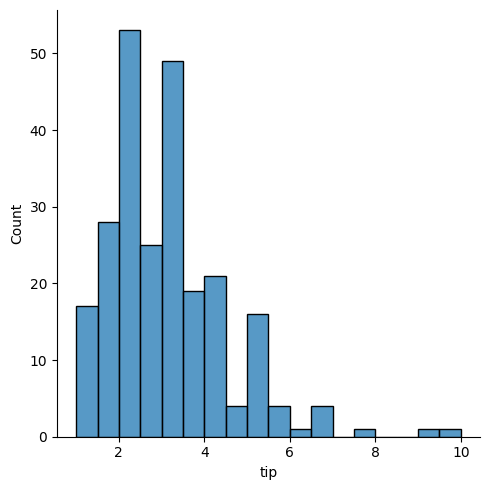

In [27]:
sns.displot(df['tip'])

**bins=10 (Histogram bars)**

 This controls:

- How many bars (groups) your data is divided into intervals/ranges

**KDE = Kernel Density Estimation**

- It draws a smooth curve showing data distribution

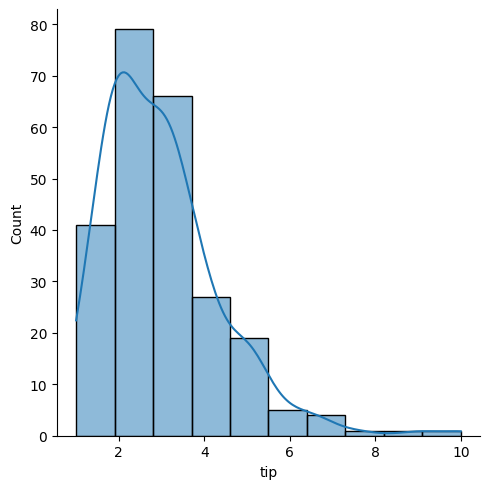

In [31]:
sns.displot(df['tip'], kde=True, bins=10)

**Categorical Plots**

- Seaborn also helps us in doing the analysis on Categorical Data points. In this section we will discuss about

1. boxplot
2. violinplot
3. countplot
4. bar plot

COUNTPLOT either you have x values or y values

<Axes: xlabel='day', ylabel='count'>

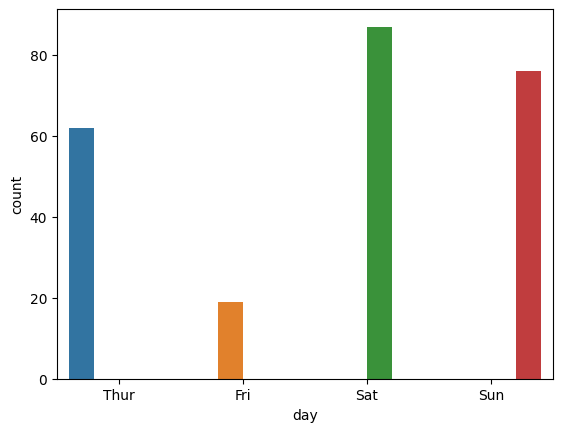

In [38]:
sns.countplot(x='day', hue='day', data=df)

<Axes: xlabel='count', ylabel='smoker'>

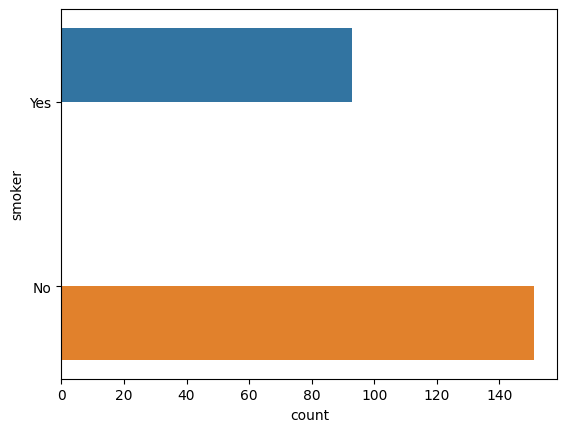

In [39]:
sns.countplot(y='smoker', hue='smoker', data=df)

BARPLOT YOU HAVE BOTH THE VALUES X AND Y

<Axes: xlabel='total_bill', ylabel='smoker'>

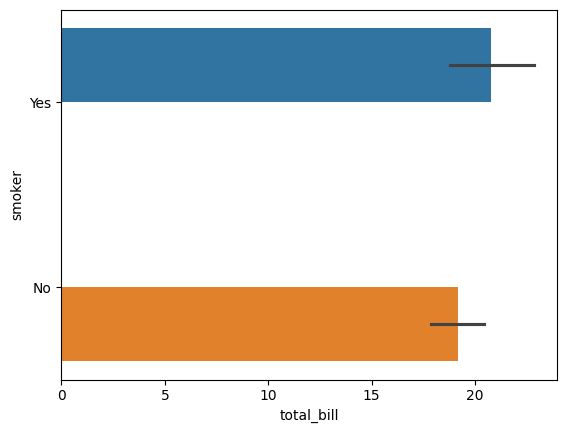

In [41]:
sns.barplot(x='total_bill', y='smoker', hue='smoker', data=df)

<Axes: xlabel='smoker', ylabel='total_bill'>

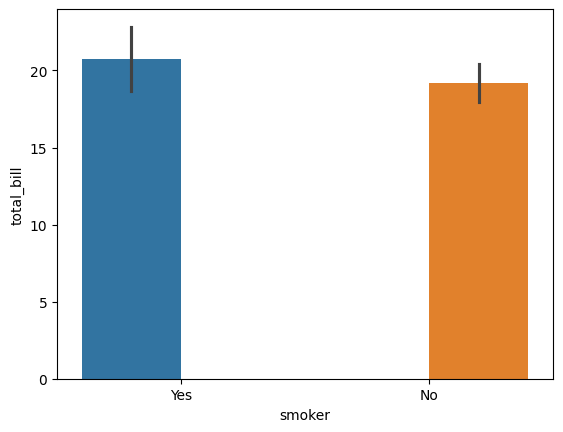

In [43]:
sns.barplot(x='smoker', y='total_bill', hue='smoker', data=df)

Box plot
A box and whisker plot (sometimes called a boxplot) is a graph that presents information from a five-number summary.

<Axes: xlabel='smoker', ylabel='total_bill'>

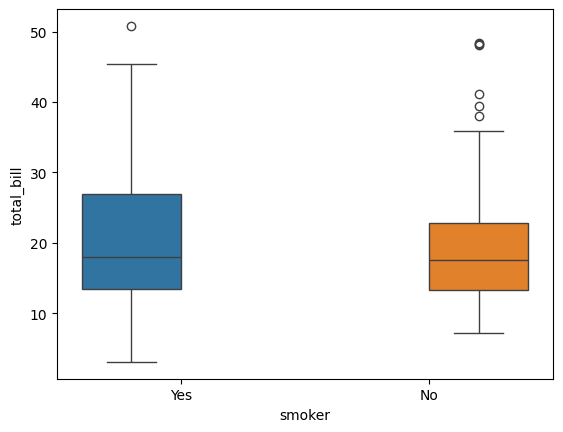

In [8]:
sns.boxplot(x='smoker', y='total_bill', hue='smoker', data=df)

each boxplot has its own 5-number key

1. Minimum
- Lowest total_bill in that group
- Bottom whisker
- ≈ 3.07(according to the tip.csv dataset)
2.  Q1 (25%)
- Bottom of the box
- 25% bills are below this
- ≈ 13.35
3. Median (50%)
- Line inside the box
- Typical bill amount
- ≈ 17.80
4. Q3 (75%)
- Top of the box
- 75% bills are below this
- ≈ 24.13
5.  Maximum
- Top whisker
- Highest bill (excluding outliers)
- ≈ 50.81


C:\Users\yashs\AppData\Local\Temp\ipykernel_13824\1338029446.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='day', y='total_bill', data=df, palette='rainbow')


<Axes: xlabel='day', ylabel='total_bill'>

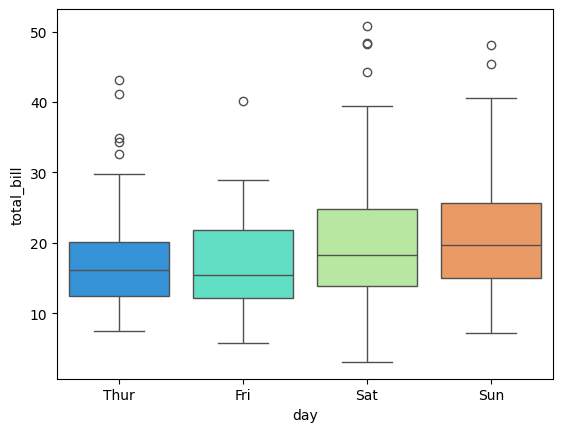

In [10]:
sns.boxplot(x='day', y='total_bill', data=df, palette='rainbow')

<Axes: >

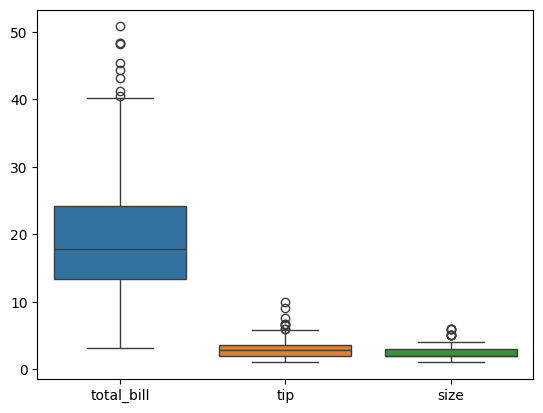

In [11]:
sns.boxplot(data=df, orient='v')

1. Vertical orientation:('v')
- X-axis → column names (total_bill, tip, size)
- Y-axis → values

2. Horizontal orientation ('h')
- X-axis → values
- Y-axis → column names

<Axes: >

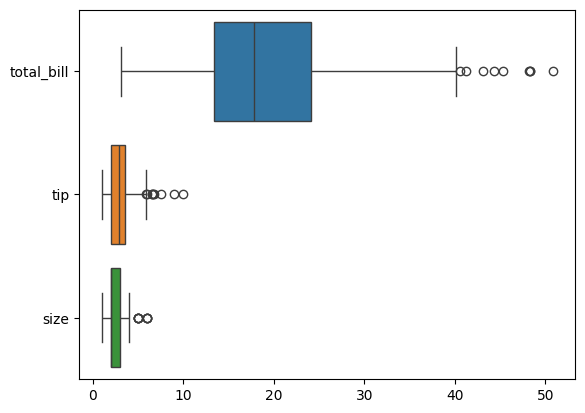

In [12]:
sns.boxplot(data=df, orient='h')

<Axes: xlabel='day', ylabel='total_bill'>

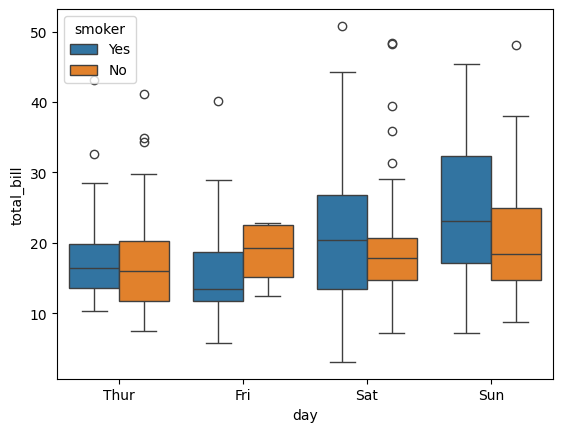

In [15]:
sns.boxplot(x='day', y='total_bill', hue='smoker', data=df)

<Axes: xlabel='total_bill', ylabel='day'>

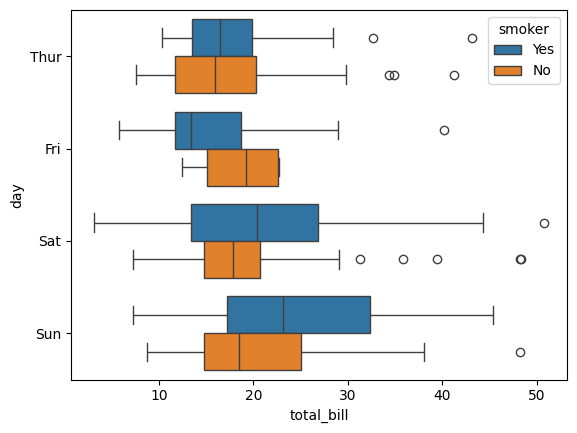

In [16]:
sns.boxplot(x='total_bill', y='day', hue='smoker', data=df)

**Violin Plot**
- Violin plot helps us to see both the distribution of data in terms of Kernel density estimation and the box plot

C:\Users\yashs\AppData\Local\Temp\ipykernel_13824\3285456979.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='total_bill', y='day', data=df, palette="rainbow")


<Axes: xlabel='total_bill', ylabel='day'>

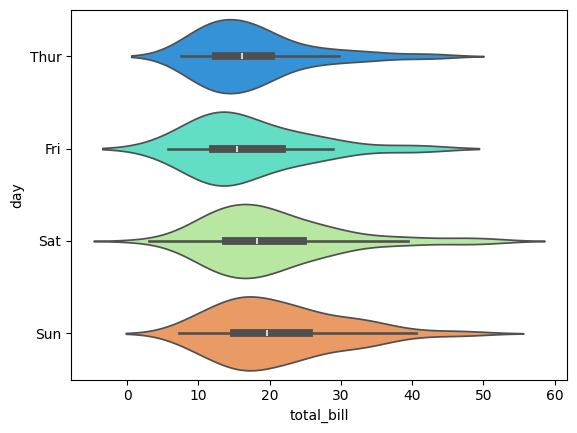

In [17]:
sns.violinplot(x='total_bill', y='day', data=df, palette="rainbow")

## 📊 Violin Plot Interpretation

### 1. Shape (Width of Violin)
- Wider area → more customers paid that amount  
- Narrow area → fewer customers  

- Example:  
If the middle is wide → most bills are around that value  

---

### 2. White Dot / Line Inside
- Represents the **median (middle value)** of the data  

---

### 3. Thick Bar Inside
- Represents the **Interquartile Range (IQR)**  
- Covers values from **Q1 (25%) to Q3 (75%)**  
- Same concept as in a boxplot  

---

### 4. Ends of the Violin
- Represent the **full range of data**  
- From **minimum to maximum values**  